# Step 1 — Stock Market Data Collection


## 1. Objective


In [1]:
# %pip install yfinance pandas numpy pyarrow matplotlib

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


## 2. Project Configuration


In [2]:
TICKERS = ["AAPL", "MSFT", "NVDA", "TSLA"]

START_DATE = "2021-02-01"
END_DATE = "2024-01-31"

OUTPUT_DIR = Path("../data/raw")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Tickers:", TICKERS)
print("Start date:", START_DATE)
print("End date (exclusive):", END_DATE)
print("Output directory:", OUTPUT_DIR.resolve())


Tickers: ['AAPL', 'MSFT', 'NVDA', 'TSLA']
Start date: 2021-02-01
End date (exclusive): 2024-01-31
Output directory: D:\Projects\stock-market-prediction\data\raw


## 3. Download Historical Stock Data


In [3]:
print("Downloading stock-market data...")

raw_data = yf.download(
    TICKERS,
    start=START_DATE,
    end=END_DATE,
    interval="1d",
    auto_adjust=False,
    actions=False,
    group_by="ticker",
    threads=True,
    progress=True
)

print("\nDownload completed.")
print("Raw data shape:", raw_data.shape)


[*********************100%***********************]  4 of 4 completed


Download completed.
Raw data shape: (754, 24)


## 4. Convert to One Combined Dataset


In [4]:
frames = []

for ticker in TICKERS:
    ticker_data = raw_data[ticker].copy()
    ticker_data = ticker_data.reset_index()
    ticker_data["Ticker"] = ticker
    frames.append(ticker_data)

stock_data = pd.concat(frames, ignore_index=True)

print("Combined dataset created.")
print("Shape:", stock_data.shape)


Combined dataset created.
Shape: (3016, 8)


In [5]:
stock_data = stock_data.rename(columns={
    "Adj Close": "Adj_Close"
})

stock_data = stock_data[
    [
        "Date",
        "Ticker",
        "Open",
        "High",
        "Low",
        "Close",
        "Adj_Close",
        "Volume"
    ]
]

stock_data["Date"] = pd.to_datetime(stock_data["Date"])

stock_data = stock_data.sort_values(
    ["Date", "Ticker"]
).reset_index(drop=True)

print(stock_data.head(12))


Price       Date Ticker        Open        High         Low       Close  \
0     2021-02-01   AAPL  133.750000  135.380005  130.929993  134.139999   
1     2021-02-01   MSFT  235.059998  242.500000  232.429993  239.649994   
2     2021-02-01   NVDA   13.053250   13.270750   12.902750   13.237000   
3     2021-02-01   TSLA  271.429993  280.666656  265.186676  279.936676   
4     2021-02-02   AAPL  135.729996  136.309998  134.610001  134.990005   
5     2021-02-02   MSFT  241.300003  242.309998  238.690002  239.509995   
6     2021-02-02   NVDA   13.398750   13.572000   13.285500   13.556750   
7     2021-02-02   TSLA  281.559998  293.500000  280.733337  290.929993   
8     2021-02-03   AAPL  135.759995  135.770004  133.610001  133.940002   
9     2021-02-03   MSFT  239.570007  245.089996  239.259995  243.000000   
10    2021-02-03   NVDA   13.636000   13.931750   13.516500   13.530500   
11    2021-02-03   TSLA  292.339996  292.693329  284.353333  284.896667   

Price   Adj_Close     Vo

## 5. Basic Dataset Inspection


In [6]:
print("Dataset shape:", stock_data.shape)
                
print("\nColumns:")
print(stock_data.columns.tolist())

print("\nFirst 10 rows:")
display(stock_data.head(10))


Dataset shape: (3016, 8)

Columns:
['Date', 'Ticker', 'Open', 'High', 'Low', 'Close', 'Adj_Close', 'Volume']

First 10 rows:


Price,Date,Ticker,Open,High,Low,Close,Adj_Close,Volume
0,2021-02-01,AAPL,133.750000,135.380005,130.929993,134.139999,130.224442,106239800
1,2021-02-01,MSFT,235.059998,242.500000,232.429993,239.649994,228.934204,33314200
2,2021-02-01,NVDA,13.053250,13.270750,12.902750,13.237000,13.183801,217204000
3,2021-02-01,TSLA,271.429993,280.666656,265.186676,279.936676,279.936676,76174200
4,2021-02-02,AAPL,135.729996,136.309998,134.610001,134.990005,131.049622,83305400
5,2021-02-02,MSFT,241.300003,242.309998,238.690002,239.509995,228.800430,25916300
6,2021-02-02,NVDA,13.398750,13.572000,13.285500,13.556750,13.502266,220440000
7,2021-02-02,TSLA,281.559998,293.500000,280.733337,290.929993,290.929993,73038600
8,2021-02-03,AAPL,135.759995,135.770004,133.610001,133.940002,130.030258,89880900
9,2021-02-03,MSFT,239.570007,245.089996,239.259995,243.000000,232.134415,27158100


In [7]:
# COMPANY COVERAGE

print(stock_data["Ticker"].value_counts())


Ticker
AAPL    754
MSFT    754
NVDA    754
TSLA    754
Name: count, dtype: int64


In [8]:
# DATE RANGE

print("Minimum date:", stock_data["Date"].min())
print("Maximum date:", stock_data["Date"].max())


Minimum date: 2021-02-01 00:00:00
Maximum date: 2024-01-30 00:00:00


## 6. Data Quality Checks


In [9]:
missing_values = stock_data.isna().sum()
print(missing_values)


Price
Date         0
Ticker       0
Open         0
High         0
Low          0
Close        0
Adj_Close    0
Volume       0
dtype: int64


In [10]:
duplicate_count = stock_data.duplicated(
    subset=["Date", "Ticker"]
).sum()

print("Duplicate Date + Ticker records:", duplicate_count)


Duplicate Date + Ticker records: 0


In [11]:
price_columns = [
    "Open",
    "High",
    "Low",
    "Close",
    "Adj_Close"
]

for column in price_columns:
    invalid_count = (stock_data[column] <= 0).sum()
    print(f"{column}: {invalid_count} invalid values")


Open: 0 invalid values
High: 0 invalid values
Low: 0 invalid values
Close: 0 invalid values
Adj_Close: 0 invalid values


In [12]:
invalid_ohlc = stock_data[
    (stock_data["High"] < stock_data["Open"]) |
    (stock_data["High"] < stock_data["Close"]) |
    (stock_data["Low"] > stock_data["Open"]) |
    (stock_data["Low"] > stock_data["Close"])
]

print("Invalid OHLC records:", len(invalid_ohlc))

if len(invalid_ohlc) > 0:
    display(invalid_ohlc)


Invalid OHLC records: 0


In [13]:
coverage = (
    stock_data
    .groupby("Ticker")
    .agg(
        Start_Date=("Date", "min"),
        End_Date=("Date", "max"),
        Trading_Days=("Date", "count")
    )
    .reset_index()
)

display(coverage)


,Ticker,Start_Date,End_Date,Trading_Days
0,AAPL,2021-02-01,2024-01-30,754
1,MSFT,2021-02-01,2024-01-30,754
2,NVDA,2021-02-01,2024-01-30,754
3,TSLA,2021-02-01,2024-01-30,754


## 7. Save the Raw Combined Dataset


In [14]:
csv_path = OUTPUT_DIR / "combined_stock_data.csv"
parquet_path = OUTPUT_DIR / "combined_stock_data.parquet"

stock_data.to_csv(csv_path, index=False)
stock_data.to_parquet(parquet_path, index=False)

print("CSV saved to:")
print(csv_path.resolve())

print("\nParquet saved to:")
print(parquet_path.resolve())


CSV saved to:
D:\Projects\stock-market-prediction\data\raw\combined_stock_data.csv

Parquet saved to:
D:\Projects\stock-market-prediction\data\raw\combined_stock_data.parquet


## 8. Exploratory Price Visualization


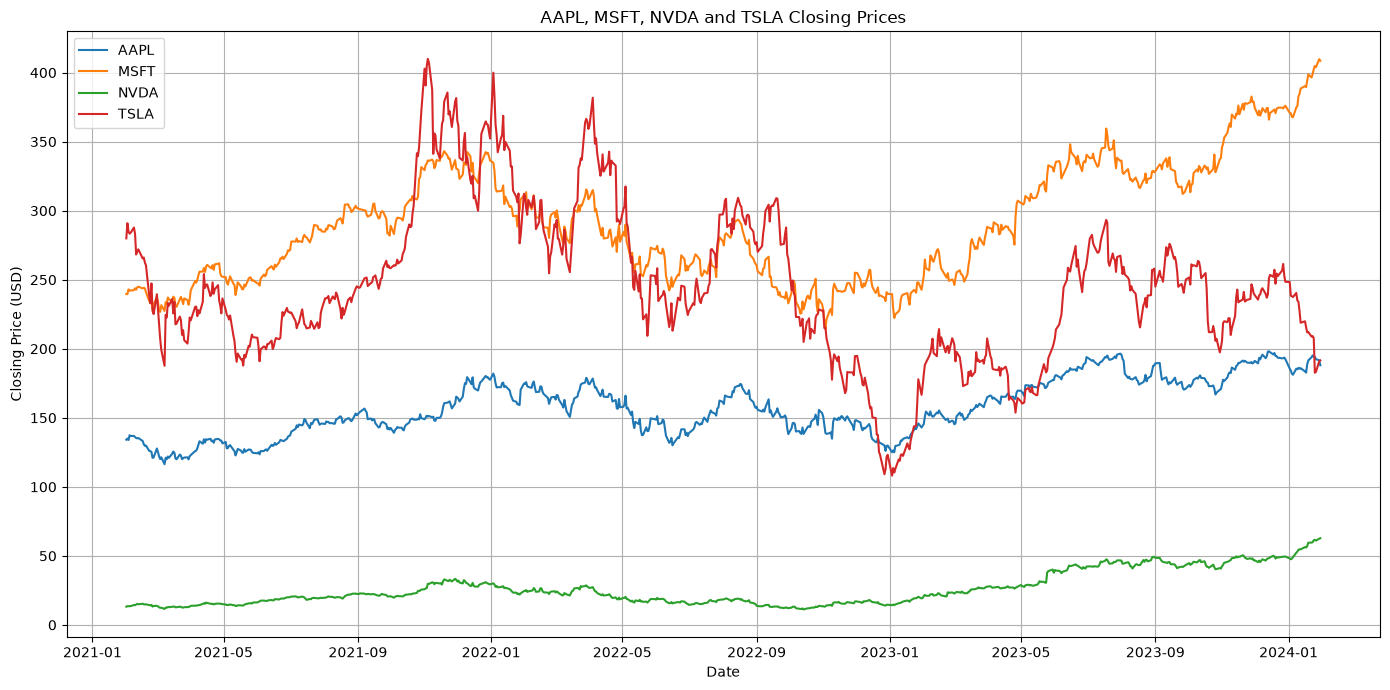

In [15]:
plt.figure(figsize=(14, 7))

for ticker in TICKERS:
    company_data = stock_data[
        stock_data["Ticker"] == ticker
    ].sort_values("Date")

    plt.plot(
        company_data["Date"],
        company_data["Close"],
        label=ticker
    )

plt.title("AAPL, MSFT, NVDA and TSLA Closing Prices")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## 9. Final Step 1 Validation


In [16]:
print("=" * 60)
print("STEP 1 VALIDATION")
print("=" * 60)

print("\nDataset shape:")
print(stock_data.shape)

print("\nColumns:")
print(stock_data.columns.tolist())

print("\nCompanies:")
print(stock_data["Ticker"].value_counts())

print("\nDate range:")
print(stock_data["Date"].min(), "to", stock_data["Date"].max())

print("\nMissing values:")
print(stock_data.isna().sum())

print("\nDuplicate Date + Ticker:")
print(
    stock_data.duplicated(
        subset=["Date", "Ticker"]
    ).sum()
)

print("\nCoverage:")
display(coverage)

print("\nStep 1 complete: raw stock dataset is ready for Step 2.")


STEP 1 VALIDATION

Dataset shape:
(3016, 8)

Columns:
['Date', 'Ticker', 'Open', 'High', 'Low', 'Close', 'Adj_Close', 'Volume']

Companies:
Ticker
AAPL    754
MSFT    754
NVDA    754
TSLA    754
Name: count, dtype: int64

Date range:
2021-02-01 00:00:00 to 2024-01-30 00:00:00

Missing values:
Price
Date         0
Ticker       0
Open         0
High         0
Low          0
Close        0
Adj_Close    0
Volume       0
dtype: int64

Duplicate Date + Ticker:
0

Coverage:


,Ticker,Start_Date,End_Date,Trading_Days
0,AAPL,2021-02-01,2024-01-30,754
1,MSFT,2021-02-01,2024-01-30,754
2,NVDA,2021-02-01,2024-01-30,754
3,TSLA,2021-02-01,2024-01-30,754



Step 1 complete: raw stock dataset is ready for Step 2.
